In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.dates as mdates

In [3]:
CARIACO = pd.read_csv("../processed/CARIACO_EnvData_combined.csv")

In [9]:
CARIACO.columns

Index(['Unnamed: 0', 'tauoc', 'sst', 'sp', 'u10', 'v10', 'lsm', 'si10', 'ewss',
       'e', 'ro', 'tp', 'mtpr', 'time_month', 'O2_umol_kg', 'O2_ml_L',
       'NO3_UDO', 'PO4_UDO', 'SiO4_UDO', 'NH4_USF', 'NO2_USF', 'NO3_NO2_USF',
       'NO3_USF', 'PO4_USF', 'SiO4_USF', 'NO3_merged', 'PO4_merged',
       'SiO4_merged', 'pH_corrected', 'Salinity_bottles', 'Temperature',
       'Sigma_t', 'PrimaryProductivity', 'Chlorophyll', 'Phaeopigments',
       'source', 'Pras', 'Lut', 'Fuco', 'Perid', 'Allo', 'But_fuco',
       'Hex_fuco', 'Zea', 'Tot_Chl_b', 'DP', 'Tot_Chl_a', 'TChl', 'Chl_c1c2',
       'Chl_c3', 'DP2', 'micro', 'nano', 'pico', 'Mesh200', 'Mesh500',
       'Isotherm_21', 'MLD', 'ui', 'upwelling'],
      dtype='object')

In [24]:
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")

In [68]:
Fish = pd.read_csv("../processed/fisheries.csv")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
Fish.columns

Index(['Unnamed: 0', 'year', 'sardinelandings', 'date'], dtype='object')

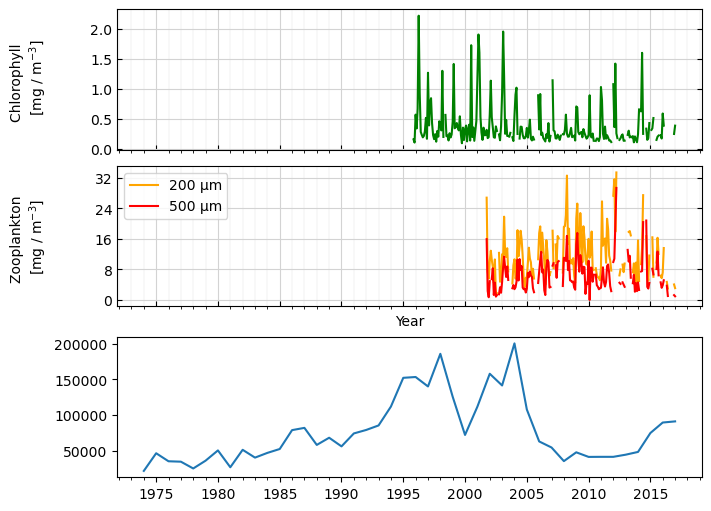

In [69]:
from matplotlib.ticker import MaxNLocator

plt.rcParams['figure.figsize'] = [7, 5]
f, ax = plt.subplots(3, 1, sharex='col', constrained_layout=True)  

color_dict={'N':'#955196','P':'green','Z1':'orange','Z2':'red'}

ax[0].plot(CARIACO.date, CARIACO.Chlorophyll, color=color_dict['P'], label='Chlorophyll')
ax[0].set_ylabel("Chlorophyll \n"+r" [mg / $ \mathrm{m^{-3}}$]")

ax[1].plot(CARIACO.date, CARIACO.Mesh200, color=color_dict['Z1'], label='200 µm')
ax[1].plot(CARIACO.date, CARIACO.Mesh500, color=color_dict['Z2'], label='500 µm')
ax[1].set_ylabel("Zooplankton \n"+r"[mg / $ \mathrm{ m^{-3} }$]")

ax[2].plot(Fish.date, Fish.sardinelandings)



for i in range(2):
    ax[i].grid(True, color='lightgrey')
    ax[i].grid(True, lw=0.2, color='lightgrey', which="minor")
    ax[i].get_yaxis().set_major_locator(MaxNLocator(nbins=5))
    ax[i].get_xaxis().set_minor_locator(mdates.YearLocator())
    ax[i].tick_params(top=False, right=True, direction="in")


# Setting the limits for all axes.
#plt.setp((ax,), ylim=(0,2.5)) #, xlim=(-1, 100)

# format labels
f.align_ylabels()

ax[0].set_xlabel('')
ax[1].set_xlabel('Year')

# show legend
ax[1].legend()


# OLD PLOT CODE AS INSPO:

In [ ]:
from matplotlib.ticker import MaxNLocator

color_dict={'N':'#955196','P':'green'}

plt.rcParams['figure.figsize'] = [5, 5]

f, ax = plt.subplots(2, 1, sharex='col', constrained_layout=True)  

for data, i, title in zip((chemostat_out, chemostat_out_sinu), (0,1), ('Sinusoidal forcing', 'Constant forcing')):
    # plot data + add labels
    data.Phytoplankton__value.plot(ax=ax[i], label='P', color=color_dict['P'])
    data.Nutrient__value.plot(ax=ax[i], label='N', color=color_dict['N'])
    ax[i].set_ylabel("["+chemostat_out_sinu.Phytoplankton__value.attrs['units']+"]")
    ax[i].set_title(title)

    # format plots
    ax[i].grid(True, color='lightgrey')
    ax[i].get_yaxis().set_major_locator(MaxNLocator(nbins=5))
    ax[i].tick_params(top=False, right=True, direction="in")


# Setting the limits for all axes.
plt.setp((ax,), xlim=(-1, 100), ylim=(0,1.5))

# format labels
f.align_ylabels()

ax[0].set_xlabel('')
ax[1].set_xlabel('Time [days]')

# show legend
ax[0].legend()

# add subplot labels
for i, label in enumerate(('(a)', '(b)')):
    ax[i].text(0.1, 1.15, label, transform=ax[i].transAxes,
      fontsize=16, fontweight='normal', va='top', ha='right')